In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [29]:
df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.shape

(19861, 60)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19861 entries, 0 to 19860
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          19861 non-null  str    
 1   host_since                                    19842 non-null  str    
 2   host_response_time                            19861 non-null  str    
 3   host_acceptance_rate                          19861 non-null  str    
 4   neighbourhood_cleansed                        19861 non-null  str    
 5   neighbourhood_group_cleansed                  19861 non-null  str    
 6   property_type                                 19861 non-null  str    
 7   room_type                                     19861 non-null  str    
 8   accommodates                                  19861 non-null  int64  
 9   bathrooms                                     19861 non-null  float64
 1

In [31]:
df.columns.tolist()

['name',
 'host_since',
 'host_response_time',
 'host_acceptance_rate',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'license',
 'instant_bookable',
 'calculated_host_lis

In [32]:
#추정 매출 공식 검증 : 매출 = 가격 * 점유율
df['clac_revenue'] = df['price'] * df['estimated_occupancy_l365d']
(df['clac_revenue'] - df['estimated_revenue_l365d']).describe()

count   19861.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
dtype: float64

In [33]:
# 계산된 매출과 추정 매출은 100% 일치
(df['clac_revenue'] == df['estimated_revenue_l365d']).mean()

np.float64(1.0)

In [34]:
#점유율
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365
df['occupancy_rate'].describe()
#에어비앤비 평균 점유율은 약 17%

count   19861.00
mean        0.17
std         0.25
min         0.00
25%         0.00
50%         0.00
75%         0.33
max         0.70
Name: occupancy_rate, dtype: float64

### estimated_revenue_l365d=price×estimated_occupancy_l365d
    - 최근 1년 기준 추정 매출 = 최근 1년동안 예약된 일수 * 1박 요금(price)
- revenue는 독립적인 정보가 아님 (새로운 정보X)
- 가설1 : 가격이 높으면 점유율이 떨어질 것이다.
    - 산점도를 통해 가격이 높아질수록 점유율이 낮아지는 경향이 일부 관찰되었다.
    - 데이터 분포가 넓고 가격이 낮은 숙소에서도 점유율이 낮은 사례가 다수 존재하여,
    - 가격만으로 점유율을 충분히 설명하기는 어려운 것으로 판단된다.

- >추가 관찰 :뉴욕 에어비앤비 숙소의 평균 점유율은 약 17% 수준으로 나타났다. 이는 전체 숙소 중 상당수가 연중 낮은 예약률을 보이고 있음을 의미한다.

<Axes: xlabel='price', ylabel='occupancy_rate'>

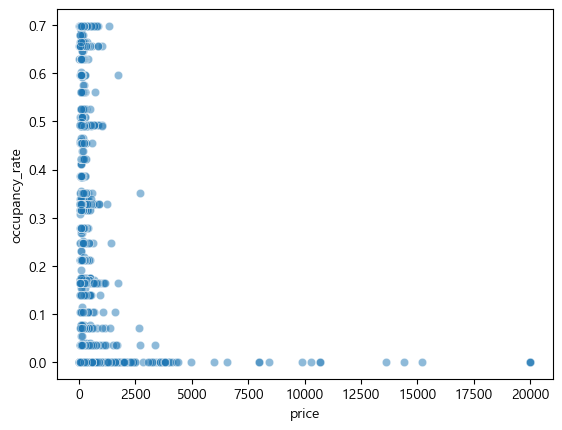

In [35]:
#가격과 점유율의 관계 확인
sns.scatterplot(
    data = df, 
    x= 'price',
    y= 'occupancy_rate',
    alpha = 0.5
)
#인사이트1 : price<1000 구간에 많이 몰려있음을 확인
#인사이트2 : 가격이 높아질수록 점유율이 낮아지는 경향이 있음
#인사이트3 : 고가 숙소의 경우 점유율이 낮거나 예약이 거의 없는 사례도 일부 관찰
#인사이트4 : 낮은 가격의 숙소에서도 점유율이 낮은 사례가 다수 존재하여 가격만으로 점유율이 결정되지는 않는 것으로 보임

<Axes: xlabel='estimated_occupancy_l365d', ylabel='Count'>

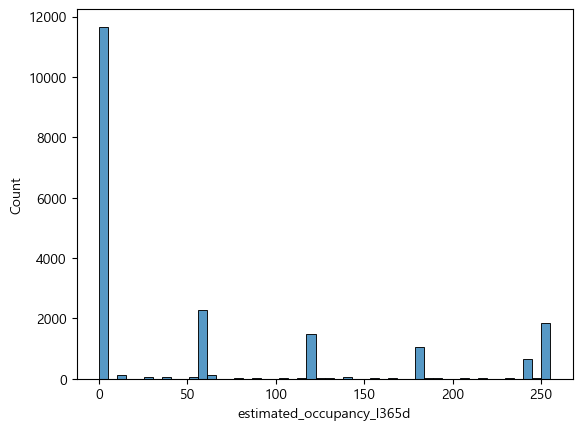

In [36]:
sns.histplot(df['estimated_occupancy_l365d'], bins=50)

<Axes: xlabel='estimated_revenue_l365d', ylabel='Count'>

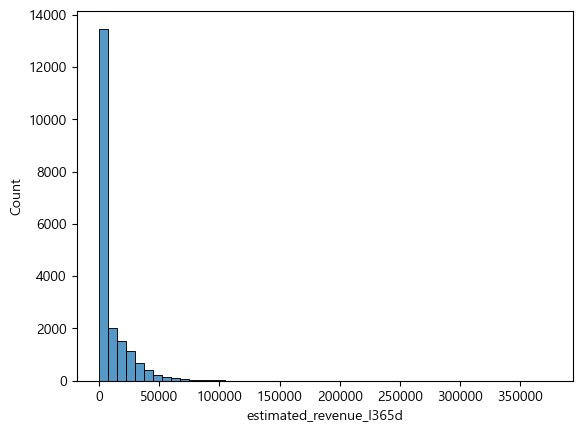

In [37]:
sns.histplot(df['estimated_revenue_l365d'], bins=50)